# ABM: bicicletas compartidas y congestión vehicular

## Entorno, versiones y compatibilidad

In [2]:
import warnings
warnings.filterwarnings("ignore")

import sys, platform
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import mesa

%matplotlib inline

try:
    from mesa.time import RandomActivation, SimultaneousActivation
    MESA2 = True
except ImportError:                 # Mesa >= 3.0: schedulers removidos
    MESA2 = False

### Parámetros del modelo

In [3]:
SEED = 42 # semilla maestra
N_COMMUTERS = 150 # numero de CommutterAgent
GRID_W, GRID_H = 20, 20 # cuadricula del centro urbano
UMBRAL_BICI = 3.0 # km, umbral de la regla de decision
DIST_MIN = 0.3 # km, cota inferior fisica para truncacion
CAP_CELDA = 2 # vehiculos por celda antes de considerarla congestionada

MU = np.array([8500.0, 6.5]) # (ingreso Q/mes, distancia km)
SIGMA = np.array([[4_000_000.0, -800.0],
                  [     -800.0,    4.0]])

print("mu    =", MU)
print("Sigma =\n", SIGMA)

mu    = [8.5e+03 6.5e+00]
Sigma =
 [[ 4.e+06 -8.e+02]
 [-8.e+02  4.e+00]]


# Task 1

## Task 1.1 Inicialización por Cholesky, Regla de Decisión y Modo de Scheduling

### a.

#### Fundamento Matemático

Sea $\boldsymbol{\Sigma}$ simétrica y definida positiva. Su descomposición de Cholesky es la factorización:
$$\boldsymbol{\Sigma} = \mathbf{L} \mathbf{L}^{\top}, \qquad \mathbf{L} \text{ triangular inferior}$$

Si $\mathbf{Z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I}_k)$ y definimos $\mathbf{X} = \boldsymbol{\mu} + \mathbf{Z}\mathbf{L}^{\top}$, entonces:
$$\mathbb{E}[\mathbf{X}] = \boldsymbol{\mu}, \qquad \operatorname{Cov}(\mathbf{X}) = \mathbf{L} \operatorname{Cov}(\mathbf{Z}) \mathbf{L}^{\top} = \mathbf{L} \mathbf{I} \mathbf{L}^{\top} = \mathbf{L} \mathbf{L}^{\top} = \boldsymbol{\Sigma}$$
por lo que $\mathbf{X} \sim \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$.

**Detalle de implementación:** Con `Z` almacenado por filas, de dimensión $(n, 2)$, la transformación matricial conforme es `X = mu + Z @ L.T`.

#### Correlación teórica esperada

$$\rho = \frac{\sigma_{12}}{\sigma_1 \sigma_2} = \frac{-800}{\sqrt{4{,}000{,}000}\cdot\sqrt{4}} = \frac{-800}{2000 \cdot 2} = -0.20$$


In [4]:
def sample_commuter_attributes(n, mu, sigma, rng, dist_min=DIST_MIN): # Genera n vectores X ~ N(mu, Sigma) por descomposicion de Cholesky.
    # Verificacion previa: Cholesky exige simetria y definicion positiva
    assert np.allclose(sigma, sigma.T), "Sigma no es simetrica"
    assert np.all(np.linalg.eigvals(sigma) > 0), "Sigma no es definida positiva"

    L = np.linalg.cholesky(sigma)          # Sigma = L @ L.T
    Z = rng.standard_normal((n, 2))        # Z ~ N(0, I)
    X = mu + Z @ L.T                       # X ~ N(mu, Sigma)

    # Truncacion: la normal asigna masa a distancias/ingresos negativos.
    # Se remuestrea el VECTOR COMPLETO invalido, no la componente aislada,
    # para no romper la estructura de dependencia entre atributos.
    n_resampled = 0
    invalid = (X[:, 1] < dist_min) | (X[:, 0] <= 0)
    while invalid.any():
        k = int(invalid.sum())
        n_resampled += k
        X[invalid] = mu + rng.standard_normal((k, 2)) @ L.T
        invalid = (X[:, 1] < dist_min) | (X[:, 0] <= 0)

    return X, L, n_resampled
    #X : ndarray (n, 2)   atributos (ingreso, distancia)
    #L : ndarray (2, 2)   factor de Cholesky, Sigma = L @ L.T
    #n_resampled : int    vectores remuestreados por truncacion

In [5]:
rng = np.random.default_rng(SEED)
X, L, n_res = sample_commuter_attributes(N_COMMUTERS, MU, SIGMA, rng)

print("Factor de Cholesky L:")
print(np.round(L, 6))
print("\nVerificacion  L @ L.T == Sigma :", np.allclose(L @ L.T, SIGMA))
print(f"Vectores remuestreados por truncacion (dist < {DIST_MIN} km): {n_res}")
print(f"\nForma de X: {X.shape}")
print("Primeras 5 filas (ingreso Q, distancia km):")
print(np.round(X[:5], 2))

Factor de Cholesky L:
[[ 2.000000e+03  0.000000e+00]
 [-4.000000e-01  1.959592e+00]]

Verificacion  L @ L.T == Sigma : True
Vectores remuestreados por truncacion (dist < 0.3 km): 0

Forma de X: (150, 2)
Primeras 5 filas (ingreso Q, distancia km):
[[9.10943e+03 4.34000e+00]
 [1.00009e+04 8.04000e+00]
 [4.59793e+03 4.73000e+00]
 [8.75568e+03 5.83000e+00]
 [8.46640e+03 4.84000e+00]]


#### Verificación de momentos muestrales

In [6]:
import math

def momentos(X, mu, sigma):
    filas = [
        ("media ingreso",    mu[0],                        X[:, 0].mean()),
        ("media distancia",  mu[1],                        X[:, 1].mean()),
        ("sd ingreso",       math.sqrt(sigma[0, 0]),       X[:, 0].std(ddof=1)),
        ("sd distancia",     math.sqrt(sigma[1, 1]),       X[:, 1].std(ddof=1)),
        ("covarianza",       sigma[0, 1],                  np.cov(X.T, ddof=1)[0, 1]),
    ]
    print(f"{'estadistico':<18}{'teorico':>14}{'muestral':>14}{'error rel.':>13}")
    print("-" * 59)
    for nombre, teo, mue in filas:
        err = abs(mue - teo) / abs(teo)
        print(f"{nombre:<18}{teo:>14.2f}{mue:>14.2f}{err:>12.1%}")

momentos(X, MU, SIGMA)

estadistico              teorico      muestral   error rel.
-----------------------------------------------------------
media ingreso            8500.00       8462.29        0.4%
media distancia             6.50          6.38        1.8%
sd ingreso               2000.00       1937.70        3.1%
sd distancia                2.00          1.76       12.0%
covarianza               -800.00       -473.37       40.8%


#### Correlación muestral e intervalo de confianza de Fisher

Para juzgar si $r$ es *consistente* con $\rho$ no basta compararlos: hace falta el error
de muestreo. Se usa la transformación de Fisher, que normaliza aproximadamente el
estadístico:

$$z = \operatorname{arctanh}(r), \qquad
\operatorname{SE}(z) = \frac{1}{\sqrt{n-3}}, \qquad
\text{IC}_{95\%}(\rho) = \tanh\!\left(z \pm 1.96\,\operatorname{SE}(z)\right)$$


In [7]:
def correlation_report(X, sigma): # Correlacion muestral, teorica e IC 95% por transformacion de Fisher.
    n = X.shape[0]
    r   = float(np.corrcoef(X[:, 0], X[:, 1])[0, 1])
    rho = float(sigma[0, 1] / np.sqrt(sigma[0, 0] * sigma[1, 1]))

    z  = np.arctanh(r)
    se = 1.0 / np.sqrt(n - 3)
    lo, hi = np.tanh(z - 1.96 * se), np.tanh(z + 1.96 * se)
    return r, rho, (float(lo), float(hi))


r, rho, ci = correlation_report(X, SIGMA)

print(f"rho teorica     = {rho:+.4f}")
print(f"r  muestral     = {r:+.4f}")
print(f"IC 95% (Fisher) = [{ci[0]:+.4f}, {ci[1]:+.4f}]")
print(f"SE aproximado   =  {1/np.sqrt(N_COMMUTERS-3):.4f}")
print()
print(f"[OK] signo de r consistente con cov = {SIGMA[0,1]:.0f} < 0 : {r < 0}")
print(f"[OK] rho teorica contenida en el IC 95%                : {ci[0] <= rho <= ci[1]}")

rho teorica     = -0.2000
r  muestral     = -0.1388
IC 95% (Fisher) = [-0.2925, +0.0220]
SE aproximado   =  0.0825

[OK] signo de r consistente con cov = -800 < 0 : True
[OK] rho teorica contenida en el IC 95%                : True


#### Diagrama de dispersión de atributos generados

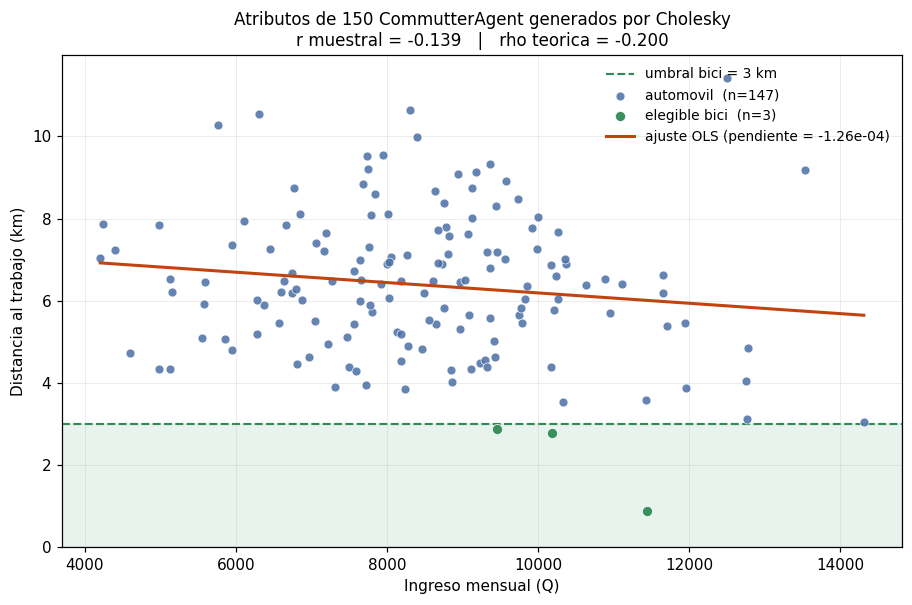

In [8]:
def plot_attributes(X, r, rho, umbral=UMBRAL_BICI):
    ing, dist = X[:, 0], X[:, 1]
    corta = dist <= umbral

    fig, ax = plt.subplots(figsize=(8.4, 5.6), dpi=110)

    ax.axhspan(0, umbral, color="#2e8b57", alpha=0.10, zorder=0)
    ax.axhline(umbral, color="#2e8b57", ls="--", lw=1.4, zorder=1,
               label=f"umbral bici = {umbral:.0f} km")

    ax.scatter(ing[~corta], dist[~corta], s=34, c="#4a6fa5", alpha=0.85,
               edgecolor="white", lw=0.5, zorder=3,
               label=f"automovil  (n={np.sum(~corta)})")
    ax.scatter(ing[corta], dist[corta], s=44, c="#2e8b57", alpha=0.95,
               edgecolor="white", lw=0.5, zorder=3,
               label=f"elegible bici  (n={np.sum(corta)})")

    b, a = np.polyfit(ing, dist, 1)
    xs = np.linspace(ing.min(), ing.max(), 100)
    ax.plot(xs, a + b * xs, color="#c1440e", lw=2, zorder=4,
            label=f"ajuste OLS (pendiente = {b:.2e})")

    ax.set_xlabel("Ingreso mensual (Q)")
    ax.set_ylabel("Distancia al trabajo (km)")
    ax.set_title(f"Atributos de {X.shape[0]} CommutterAgent generados por Cholesky\n"
                 f"r muestral = {r:+.3f}   |   rho teorica = {rho:+.3f}", fontsize=11)
    ax.legend(frameon=False, fontsize=9, loc="upper right")
    ax.grid(alpha=0.25, lw=0.6)
    ax.set_ylim(bottom=0)
    fig.tight_layout()
    return fig, ax


fig, ax = plot_attributes(X, r, rho)
plt.show()

### b.

Las clases de agente se definen en la siguiente celda con el método solicitado `choose_transport(self)` y la propuesta estocástica `choose_transport_stochastic(self)`.


In [9]:
class CommutterAgent(mesa.Agent): #Persona que se desplaza diariamente al centro urbano.

    def __init__(self, unique_id, model, ingreso, distancia, propension_bici=None):
        if MESA2:
            super().__init__(unique_id, model)
        else:                                  # Mesa 3.x asigna unique_id solo
            super().__init__(model)
            self.unique_id = unique_id

        # estado interno
        self.ingreso         = float(ingreso)
        self.distancia       = float(distancia)
        self.propension_bici = propension_bici     # solo variante estocastica
        self.modo            = None
        self.vehiculo        = None

    # regla DETERMINISTA (la solicitada)
    def choose_transport(self): # modo = bicicleta si distancia <= 3 km AND politica_activa; si no, automovil.
        if self.distancia <= UMBRAL_BICI and self.model.politica_activa:
            self.modo = "bicicleta"
        else:
            self.modo = "automovil"
        return self.modo

    # variante ESTOCASTICA (propuesta)
    def choose_transport_stochastic(self):
        if not self.model.politica_activa:
            self.modo = "automovil"
            return self.modo

        b0, b1 = self.model.beta0, self.model.beta1
        p = self.propension_bici / (1.0 + np.exp(-(b0 + b1 * self.distancia)))
        self.modo = "bicicleta" if self.random.random() < p else "automovil"
        return self.modo

    # ciclo de vida
    def step(self):
        self.model.activaciones[self.unique_id] += 1     # verificacion del scheduler
        self.choose_transport()
        if self.modo == "automovil":
            self.move()

    def move(self): # Movilidad en cuadricula: una celda adyacente (vecindad de Moore).
        vecinas = self.model.grid.get_neighborhood(self.pos, moore=True,
                                                   include_center=False)
        destino = self.random.choice(vecinas)
        self.model.grid.move_agent(self, destino)
        self.model.ocupacion[destino] += 1                # comunicacion por entorno


class VehicleAgent(mesa.Agent): # Vehiculo en circulacion; ocupa capacidad vial en su celda.

    def __init__(self, unique_id, model, conductor=None):
        if MESA2:
            super().__init__(unique_id, model)
        else:
            super().__init__(model)
            self.unique_id = unique_id
        self.conductor = conductor

    def step(self):
        self.model.activaciones[self.unique_id] += 1
        vecinas = self.model.grid.get_neighborhood(self.pos, moore=True,
                                                   include_center=False)
        destino = self.random.choice(vecinas)
        self.model.grid.move_agent(self, destino)
        self.model.ocupacion[destino] += 1

print("Clases CommutterAgent y VehicleAgent definidas.")

Clases CommutterAgent y VehicleAgent definidas.


La siguiente celda evalúa esta propiedad de forma vectorizada sobre la población generada:

In [10]:
def aplicar_regla(distancias, politica_activa, umbral=UMBRAL_BICI):
    """Equivalente vectorizado de CommutterAgent.choose_transport()."""
    elegibles = (distancias <= umbral) & bool(politica_activa)
    return np.where(elegibles, "bicicleta", "automovil")


print(f"{'escenario':<26}{'bicicleta':>11}{'automovil':>12}{'cuota bici':>13}")
print("-" * 62)
for politica in (False, True):
    modos = aplicar_regla(X[:, 1], politica)
    nb = int((modos == "bicicleta").sum())
    na = int((modos == "automovil").sum())
    print(f"{'politica_activa=' + str(politica):<26}{nb:>11}{na:>12}{nb/len(modos):>12.1%}")

# determinismo: evaluar 5 veces la misma poblacion
reps = [int((aplicar_regla(X[:, 1], True) == "bicicleta").sum()) for _ in range(5)]
print(f"\n5 evaluaciones sobre la misma poblacion -> {reps}   varianza = {np.var(reps):.1f}")

escenario                   bicicleta   automovil   cuota bici
--------------------------------------------------------------
politica_activa=False               0         150        0.0%
politica_activa=True                3         147        2.0%

5 evaluaciones sobre la misma poblacion -> [3, 3, 3, 3, 3]   varianza = 0.0


#### Análisis complementario: El tamaño del efecto bajo esta parametrización

Con $\text{distancia} \sim \mathcal{N}(6.5,\, 2^2)$:

$$P[\text{distancia} \le 3] = \Phi\!\left(\frac{3 - 6.5}{2}\right) = \Phi(-1.75) \approx 0.0401$$

es decir, bajo esta regla determinista la política sólo alcanza a **~4 % de la población** (~6 de 150 agentes).


In [11]:
from math import erf, sqrt

p_eleg = 0.5 * (1 + erf((UMBRAL_BICI - MU[1]) / (sqrt(SIGMA[1, 1]) * sqrt(2))))
print(f"P[distancia <= {UMBRAL_BICI:.0f} km] = {p_eleg:.4f}")
print(f"E[elegibles de {N_COMMUTERS}] = {N_COMMUTERS * p_eleg:.2f}   "
      f"sd = {np.sqrt(N_COMMUTERS * p_eleg * (1 - p_eleg)):.2f}")

# distribucion del numero de elegibles sobre 2000 semillas distintas
conteos = []
for s in range(2000):
    _rng = np.random.default_rng(s)
    Xs, _, _ = sample_commuter_attributes(N_COMMUTERS, MU, SIGMA, _rng)
    conteos.append(int((Xs[:, 1] <= UMBRAL_BICI).sum()))
conteos = np.array(conteos)

print(f"\nSobre 2000 semillas: media={conteos.mean():.2f}  min={conteos.min()}  "
      f"max={conteos.max()}  [p2.5, p97.5]=[{np.percentile(conteos,2.5):.0f}, "
      f"{np.percentile(conteos,97.5):.0f}]")
print(f"Cuota modal bici bajo politica: {conteos.mean()/N_COMMUTERS:.2%}")

# sensibilidad al umbral
print(f"\n{'umbral (km)':<14}{'P[elegible]':>13}{'E[agentes]':>13}")
print("-" * 40)
for u in (3, 4, 5, 6, 8):
    p = 0.5 * (1 + erf((u - MU[1]) / (sqrt(SIGMA[1, 1]) * sqrt(2))))
    print(f"{u:<14}{p:>12.1%}{N_COMMUTERS*p:>13.1f}")

P[distancia <= 3 km] = 0.0401
E[elegibles de 150] = 6.01   sd = 2.40



Sobre 2000 semillas: media=5.83  min=0  max=14  [p2.5, p97.5]=[2, 11]
Cuota modal bici bajo politica: 3.89%

umbral (km)     P[elegible]   E[agentes]
----------------------------------------
3                     4.0%          6.0
4                    10.6%         15.8
5                    22.7%         34.0
6                    40.1%         60.2
8                    77.3%        116.0


In [12]:
def regla_estocastica(distancias, propensiones, politica_activa, rng, beta0=2.2, beta1=-0.55): # Version vectorizada de choose_transport_stochastic().
    if not politica_activa:
        return np.full(len(distancias), "automovil")
    p = propensiones / (1.0 + np.exp(-(beta0 + beta1 * distancias)))
    return np.where(rng.random(len(distancias)) < p, "bicicleta", "automovil")


rng_demo = np.random.default_rng(SEED)
propensiones = rng_demo.beta(5.0, 2.0, size=N_COMMUTERS)

reps_s = [int((regla_estocastica(X[:, 1], propensiones, True, rng_demo) == "bicicleta").sum())
          for _ in range(10)]

print(f"Regla DETERMINISTA  -> {reps[:5]}      varianza = {np.var(reps):.2f}")
print(f"Regla ESTOCASTICA   -> {reps_s[:5]}   varianza = {np.var(reps_s):.2f}")
print(f"\nCuota bici estocastica: media = {np.mean(reps_s)/N_COMMUTERS:.1%} "
      f"(vs {np.mean(reps)/N_COMMUTERS:.1%} determinista)")
print("\nLa varianza no nula es la que da sentido a las corridas multiples y al bootstrap.")

Regla DETERMINISTA  -> [3, 3, 3, 3, 3]      varianza = 0.00
Regla ESTOCASTICA   -> [25, 28, 20, 27, 29]   varianza = 9.64

Cuota bici estocastica: media = 16.9% (vs 2.0% determinista)

La varianza no nula es la que da sentido a las corridas multiples y al bootstrap.


### c.

In [13]:
class UrbanMobilityModel(mesa.Model): # Cuadricula 20x20 del centro urbano. Scheduling ASINCRONO ALEATORIO.

    def __init__(self, politica_activa=False, n_commuters=N_COMMUTERS,
                 width=GRID_W, height=GRID_H, seed=SEED):
        super().__init__()
        self.random.seed(seed)                 # RNG de Mesa: orden del scheduler
        rng = np.random.default_rng(seed)      # RNG de NumPy: atributos

        self.politica_activa = politica_activa
        self.grid       = mesa.space.MultiGrid(width, height, torus=True)
        self.ocupacion  = np.zeros((width, height), dtype=int)
        self.activaciones = {}                 # contador para verificacion

        self.beta0, self.beta1 = 2.2, -0.55    # parametros de la variante estocastica

        # SCHEDULER: asincrono aleatorio
        if MESA2:
            self.schedule = RandomActivation(self)

        # inicializacion de agentes (Cholesky, §1)
        Xa, self.L, self.n_resampled = sample_commuter_attributes(
            n_commuters, MU, SIGMA, rng)
        self.attrs = Xa
        propensiones = rng.beta(5.0, 2.0, size=n_commuters)

        for i in range(n_commuters):
            a = CommutterAgent(i, self, Xa[i, 0], Xa[i, 1], propensiones[i])
            self.grid.place_agent(a, (int(rng.integers(width)), int(rng.integers(height))))
            self.activaciones[a.unique_id] = 0
            if MESA2:
                self.schedule.add(a)

            v = VehicleAgent(1000 + i, self, conductor=a)
            a.vehiculo = v
            self.grid.place_agent(v, a.pos)
            self.activaciones[v.unique_id] = 0
            if MESA2:
                self.schedule.add(v)

    # paso de simulacion
    def step(self):
        self.ocupacion[:] = 0
        if MESA2:
            self.schedule.step()          # RandomActivation re-baraja cada paso
        else:
            self.agents.shuffle_do("step")   # equivalente exacto en Mesa 3.x

    # observadores
    def commuters(self):
        pool = self.schedule.agents if MESA2 else self.agents
        return [a for a in pool if isinstance(a, CommutterAgent)]

    def modal_split(self):
        modos = [a.modo for a in self.commuters()]
        return {"bicicleta": modos.count("bicicleta"),
                "automovil": modos.count("automovil")}

    def congestion_index(self):
        """Fraccion de celdas con mas de CAP_CELDA vehiculos: proxy de congestion."""
        return float((self.ocupacion > CAP_CELDA).mean())

print("Clase UrbanMobilityModel definida.")

Clase UrbanMobilityModel definida.


#### Alternativa síncrona (solo para referencia y contraste)

Se incluye únicamente para contraste conceptual; **no** es el modo elegido. El patrón síncrono separa el cálculo del estado nuevo (`step`) de su aplicación (`advance`), de modo que ningún agente observa el estado actualizado de otro dentro del mismo paso.


In [14]:
class _CommutterSincrono(CommutterAgent): # Variante sincrona: step() calcula, advance() aplica.

    def step(self):
        self.model.activaciones[self.unique_id] += 1
        self._modo_siguiente = ("bicicleta"
                                if self.distancia <= UMBRAL_BICI and self.model.politica_activa
                                else "automovil")
        vecinas = self.model.grid.get_neighborhood(self.pos, moore=True,
                                                   include_center=False)
        self._pos_siguiente = self.random.choice(vecinas)

    def advance(self):
        self.modo = self._modo_siguiente
        if self.modo == "automovil":
            self.model.grid.move_agent(self, self._pos_siguiente)
            self.model.ocupacion[self._pos_siguiente] += 1

# En Mesa 2.x:   self.schedule = SimultaneousActivation(self)
# En Mesa 3.x:   self.agents.do("step"); self.agents.do("advance")
print("Variante sincrona definida (solo para analisis de sensibilidad).")

Variante sincrona definida (solo para analisis de sensibilidad).


#### Verificación del scheduler

Chequeo de verificación: *¿el scheduler activa a todos los agentes exactamente una vez por paso?*


In [15]:
N_PASOS = 10
modelo = UrbanMobilityModel(politica_activa=True, seed=SEED)

for _ in range(N_PASOS):
    modelo.step()

conteos_act = np.array(list(modelo.activaciones.values()))

print(f"Mesa {mesa.__version__}  |  ruta RandomActivation = {MESA2}")
print(f"Agentes totales: {len(conteos_act)} "
      f"({len(modelo.commuters())} commuters + {len(conteos_act) - len(modelo.commuters())} vehiculos)")
print(f"Activaciones por agente: min={conteos_act.min()}  max={conteos_act.max()}")
print(f"\n[OK] cada agente activado exactamente {N_PASOS} veces: "
      f"{bool((conteos_act == N_PASOS).all())}")
print(f"\nReparto modal      : {modelo.modal_split()}")
print(f"Indice de congestion: {modelo.congestion_index():.4f}")

Mesa 3.5.1  |  ruta RandomActivation = False
Agentes totales: 300 (150 commuters + 150 vehiculos)
Activaciones por agente: min=10  max=10

[OK] cada agente activado exactamente 10 veces: True

Reparto modal      : {'bicicleta': 3, 'automovil': 147}
Indice de congestion: 0.0475


#### Verificación de reproducibilidad

Dos instancias con la misma semilla deben producir resultados idénticos; con semillas distintas, resultados distintos.


In [16]:
def correr(politica, seed, pasos=N_PASOS):
    m = UrbanMobilityModel(politica_activa=politica, seed=seed)
    for _ in range(pasos):
        m.step()
    return m.congestion_index()

a1 = correr(True, SEED)
a2 = correr(True, SEED)
b1 = correr(True, SEED + 1)

print(f"seed={SEED}   corrida 1 -> {a1:.6f}")
print(f"seed={SEED}   corrida 2 -> {a2:.6f}")
print(f"seed={SEED+1} corrida 1 -> {b1:.6f}")
print(f"\n[OK] misma semilla => resultado identico : {a1 == a2}")
print(f"[OK] semilla distinta => resultado distinto: {a1 != b1}")

seed=42   corrida 1 -> 0.047500
seed=42   corrida 2 -> 0.047500
seed=43 corrida 1 -> 0.040000

[OK] misma semilla => resultado identico : True
[OK] semilla distinta => resultado distinto: True


## Task 1.2 movilidad dirigida, congestión y eliminación

Las clases `CommutterAgent` y `UrbanMobilityModel` se redefinen con los mismos nombres; las versiones anteriores quedan como registro de la Task 1.1.


In [17]:
CAP_CELDA = 3 # capacidad vial de una celda (commuters simultaneos)
SD_CBD= 2.0 # dispersion del distrito central de negocios (celdas)
ESCALA_KM_CELDA = 1.0 # km por celda
VENTANA_SALIDA = 5 # t_salida ~ U{0,...,4}
TORUS = False # ver 4.0(a)

print(f"capacidad por celda : {CAP_CELDA} commuters")
print(f"escala espacial : 1 celda = {ESCALA_KM_CELDA} km  -> cuadricula" f"{GRID_W}x{GRID_H} = {GRID_W*ESCALA_KM_CELDA:.0f}x{GRID_H*ESCALA_KM_CELDA:.0f} km")
print(f"ventana de salida   : {VENTANA_SALIDA} pasos")

capacidad por celda : 3 commuters
escala espacial : 1 celda = 1.0 km  -> cuadricula20x20 = 20x20 km
ventana de salida   : 5 pasos


#### Utilidades geométricas

`celdas_a_distancia` enumera todas las celdas a distancia Manhattan exactamente `d` de un
punto, dentro de los límites de la cuadrícula. Se usa para colocar el origen de cada agente
a la distancia que exige su atributo muestreado.

In [18]:
def celdas_a_distancia(centro, d, w, h): # Celdas dentro de la cuadricula a distancia Manhattan exactamente d de `centro`.
    ox, oy = centro
    out = []
    for dx in range(-d, d + 1):
        dy = d - abs(dx)
        for s in ({0} if dy == 0 else {dy, -dy}):
            x, y = ox + dx, oy + s
            if 0 <= x < w and 0 <= y < h:
                out.append((x, y))
    return out


def quitar_del_schedule(model, agente): # Elimina del schedule en la version de Mesa que corresponda.
    if MESA2:
        model.schedule.remove(agente)      # Mesa 2.x
    else:
        agente.remove()                    # Mesa 3.x: deregistra del modelo


_c = celdas_a_distancia((10, 10), 3, GRID_W, GRID_H)
print(f"celdas a distancia Manhattan 3 de (10,10): {len(_c)}")
print("todas cumplen |dx|+|dy| == 3:",
      all(abs(x - 10) + abs(y - 10) == 3 for x, y in _c))

celdas a distancia Manhattan 3 de (10,10): 12
todas cumplen |dx|+|dy| == 3: True


### a.

In [19]:
class VehicleAgent(mesa.Agent):
    def __init__(self, unique_id, model, conductor=None):
        if MESA2:
            super().__init__(unique_id, model)
        else:
            super().__init__(model)
            self.unique_id = unique_id
        self.conductor = conductor


class CommutterAgent(mesa.Agent):
    def __init__(self, unique_id, model, ingreso, distancia, destino, t_salida):
        if MESA2:
            super().__init__(unique_id, model)
        else:
            super().__init__(model)
            self.unique_id = unique_id

        self.ingreso   = float(ingreso)
        self.distancia = float(distancia)
        self.destino   = destino
        self.t_salida  = int(t_salida)

        self.modo         = None          # aun no ha elegido: percibira el entorno
        self.vehiculo     = None
        self.estado       = "En espera"
        self.pasos_espera = 0
        self.t_llegada    = None

    # percepcion LOCAL del entorno
    def congestion_percibida(self):
        """Congestion media en la vecindad de Moore. El entorno percibido es local:
        el agente NO ve el mapa global."""
        x, y = self.pos
        x0, x1 = max(0, x - 1), min(self.model.grid.width,  x + 2)
        y0, y1 = max(0, y - 1), min(self.model.grid.height, y + 2)
        return float(self.model.congestion_map[x0:x1, y0:y1].mean())

    # eleccion de modo
    def choose_transport(self):
        """Regla de Task 1.1 + canal de comunicacion por entorno (Task 1.2 punto 2)."""
        if self.distancia <= UMBRAL_BICI and self.model.politica_activa:
            self.modo = "bicicleta"
        elif (self.model.percepcion_congestion and self.model.politica_activa
              and self.distancia <= self.model.dist_max_bici
              and self.congestion_percibida() >= self.model.umbral_congestion):
            self.modo = "bicicleta"                 # cambia por congestion percibida
            self.model.n_switch_congestion += 1
        else:
            self.modo = "automovil"
        return self.modo

    # movilidad
    def _candidatos_paso(self):
        """Pasos unitarios sobre un camino Manhattan mas corto, barajados."""
        x, y = self.pos
        dx, dy = self.destino[0] - x, self.destino[1] - y
        cands = []
        if dx != 0:
            cands.append((x + (1 if dx > 0 else -1), y))
        if dy != 0:
            cands.append((x, y + (1 if dy > 0 else -1)))
        self.random.shuffle(cands)          # evita el sesgo de trayectorias en L
        return cands

    def _bloqueada(self, celda):
        n = sum(isinstance(a, CommutterAgent)
                for a in self.model.grid.get_cell_list_contents([celda]))
        return n >= CAP_CELDA

    # ciclo de vida
    def step(self):
        # GUARDA. El scheduler toma un SNAPSHOT de la lista de agentes al inicio del
        # paso (verificado en el fuente de Mesa 2.3.4 y 3.5.1) y solo omite los que la
        # referencia debil ya no resuelve. El modelo mantiene referencias fuertes a los
        # agentes llegados, asi que la referencia debil NO muere. Sin esta guarda,
        # self.pos es None -> excepcion. Evidencia empirica en §4.5.
        if self.estado == "Llegado":
            self.model.reactivaciones_post_eliminacion += 1
            return

        self.model.orden_activacion.append(self.unique_id)
        self.model.activaciones[self.unique_id] += 1

        if self.model.t < self.t_salida:          # aun no sale de casa
            return

        if self.modo is None:                     # PRIMERA activacion: elige modo
            self.choose_transport()               # <-- lee congestion_map
            self.estado = "Viajando"
            if self.modo == "automovil":
                v = VehicleAgent(1000 + self.unique_id, self.model, conductor=self)
                self.vehiculo = v
                self.model.grid.place_agent(v, self.pos)
                self.model.vehiculos.append(v)

        # un paso hacia el destino; si todo candidato esta bloqueado, ESPERA
        movido = False
        for c in self._candidatos_paso():
            if not self._bloqueada(c):
                self.model.grid.move_agent(self, c)
                if self.vehiculo is not None:
                    self.model.grid.move_agent(self.vehiculo, c)
                movido = True
                break
        if not movido:
            self.pasos_espera += 1

        if self.pos == self.destino:
            self._llegar()

    def _llegar(self): # Condicion terminal: elimina del schedule y de la cuadricula.
        self.estado    = "Llegado"
        self.t_llegada = self.model.t
        self.model.llegados.append(self)

        if not self.model.eliminar:
            return

        if self.vehiculo is not None:
            self.model.grid.remove_agent(self.vehiculo)
            self.model.vehiculos.remove(self.vehiculo)
            if not MESA2:
                self.vehiculo.remove()
            self.vehiculo = None

        self.model.grid.remove_agent(self)        # <-- grid.remove_agent(self)
        quitar_del_schedule(self.model, self)     # <-- schedule.remove(self)

print("CommutterAgent y VehicleAgent (version Task 1.2) definidos.")

CommutterAgent y VehicleAgent (version Task 1.2) definidos.


### b. `congestion_map` como variable de entorno

In [20]:
class UrbanMobilityModel(mesa.Model):
    """Cuadricula 20x20. Scheduling ASINCRONO ALEATORIO (justificado en §3)."""

    def __init__(self, politica_activa=False, n_commuters=N_COMMUTERS,
                 width=GRID_W, height=GRID_H, seed=SEED,
                 eliminar=True, percepcion_congestion=True,
                 umbral_congestion=0.8, dist_max_bici=6.0):
        super().__init__()
        self.random.seed(seed)
        rng = np.random.default_rng(seed)

        self.politica_activa       = politica_activa
        self.eliminar              = eliminar
        self.percepcion_congestion = percepcion_congestion
        self.umbral_congestion     = umbral_congestion
        self.dist_max_bici         = dist_max_bici

        self.grid = mesa.space.MultiGrid(width, height, torus=TORUS)
        self.congestion_map = np.zeros((width, height), dtype=int)   # <-- punto 2

        self.t = 0
        self.activaciones      = {}
        self.orden_activacion  = []
        self.activos_al_inicio = []
        self.llegados  = []
        self.vehiculos = []
        self.historial = []
        self.n_switch_congestion = 0
        self.reactivaciones_post_eliminacion = 0
        self.n_clipped = 0

        if MESA2:
            self.schedule = RandomActivation(self)

        # atributos correlacionados (§1)
        X, self.L, self.n_resampled = sample_commuter_attributes(
            n_commuters, MU, SIGMA, rng)
        self.attrs = X

        cx, cy = width // 2, height // 2
        for i in range(n_commuters):
            # destino en el distrito central de negocios
            dest = (int(np.clip(round(rng.normal(cx, SD_CBD)), 0, width - 1)),
                    int(np.clip(round(rng.normal(cy, SD_CBD)), 0, height - 1)))
            # origen a la distancia Manhattan que exige el atributo muestreado
            d = max(1, int(round(X[i, 1] / ESCALA_KM_CELDA)))
            cand = celdas_a_distancia(dest, d, width, height)
            while not cand:
                d -= 1
                self.n_clipped += 1
                cand = celdas_a_distancia(dest, d, width, height)
            origen = cand[int(rng.integers(len(cand)))]

            a = CommutterAgent(i, self, X[i, 0], X[i, 1], dest,
                               int(rng.integers(VENTANA_SALIDA)))
            self.grid.place_agent(a, origen)
            self.activaciones[i] = 0
            if MESA2:
                self.schedule.add(a)

        self._actualizar_congestion()

    # variable de entorno
    def _actualizar_congestion(self):
        """Recuento de VehicleAgent por celda. Version-agnostico: recorre la lista de
        vehiculos en vez de grid.coord_iter(), cuya firma cambia entre Mesa 2 y 3."""
        self.congestion_map[:] = 0
        for v in self.vehiculos:
            if v.pos is not None:
                self.congestion_map[v.pos] += 1

    # observadores
    def activos(self):
        pool = self.schedule.agents if MESA2 else self.agents
        return [a for a in pool
                if isinstance(a, CommutterAgent) and a.estado != "Llegado"]

    def indice_congestion(self):
        return float((self.congestion_map >= CAP_CELDA).mean())

    # paso de simulacion
    def step(self):
        self.activos_al_inicio = sorted(a.unique_id for a in self.activos())
        self.orden_activacion  = []

        if MESA2:
            self.schedule.step()
        else:
            self.agents.shuffle_do("step")

        self._actualizar_congestion()             # <-- AL FINAL del paso

        self.historial.append({
            "t": self.t,
            "activos":     len(self.activos()),
            "llegados":    len(self.llegados),
            "vehiculos":   len(self.vehiculos),
            "cong_media":  float(self.congestion_map.mean()),
            "cong_max":    int(self.congestion_map.max()),
            "celdas_cong": int((self.congestion_map >= CAP_CELDA).sum()),
        })
        self.t += 1

    def correr(self, max_pasos=120, parar_si_vacio=True):
        for _ in range(max_pasos):
            self.step()
            if parar_si_vacio and len(self.activos()) == 0:
                break
        return self

print("UrbanMobilityModel (version Task 1.2) definido.")

UrbanMobilityModel (version Task 1.2) definido.


#### Corrida de los dos escenarios

In [21]:
resultados = {}
for pol in (False, True):
    m = UrbanMobilityModel(politica_activa=pol, seed=SEED).correr(120)
    resultados[pol] = m
    modos = [a.modo for a in m.llegados]
    print(f"politica_activa = {pol}")
    print(f"  pasos hasta vaciar la red : {m.t}")
    print(f"  llegados                  : {len(m.llegados)}/{N_COMMUTERS}")
    print(f"  reparto modal             : bici={modos.count('bicicleta')}  "
          f"auto={modos.count('automovil')}")
    print(f"    por regla de distancia          : "
          f"{modos.count('bicicleta') - m.n_switch_congestion}")
    print(f"    por congestion percibida        : {m.n_switch_congestion}")
    print(f"  congestion media pico     : {max(h['cong_media'] for h in m.historial):.4f}")
    print(f"  celdas saturadas (pico)   : {max(h['celdas_cong'] for h in m.historial)}")
    print(f"  pasos de espera / agente  : "
          f"{np.mean([a.pasos_espera for a in m.llegados]):.2f}")
    print(f"  tiempo de viaje medio     : "
          f"{np.mean([a.t_llegada - a.t_salida for a in m.llegados]):.2f} pasos")
    print()

politica_activa = False
  pasos hasta vaciar la red : 15
  llegados                  : 150/150
  reparto modal             : bici=0  auto=150
    por regla de distancia          : 0
    por congestion percibida        : 0
  congestion media pico     : 0.3375
  celdas saturadas (pico)   : 11
  pasos de espera / agente  : 0.29
  tiempo de viaje medio     : 5.66 pasos

politica_activa = True
  pasos hasta vaciar la red : 15
  llegados                  : 150/150
  reparto modal             : bici=9  auto=141
    por regla de distancia          : 3
    por congestion percibida        : 6
  congestion media pico     : 0.3250
  celdas saturadas (pico)   : 10
  pasos de espera / agente  : 0.25
  tiempo de viaje medio     : 5.61 pasos



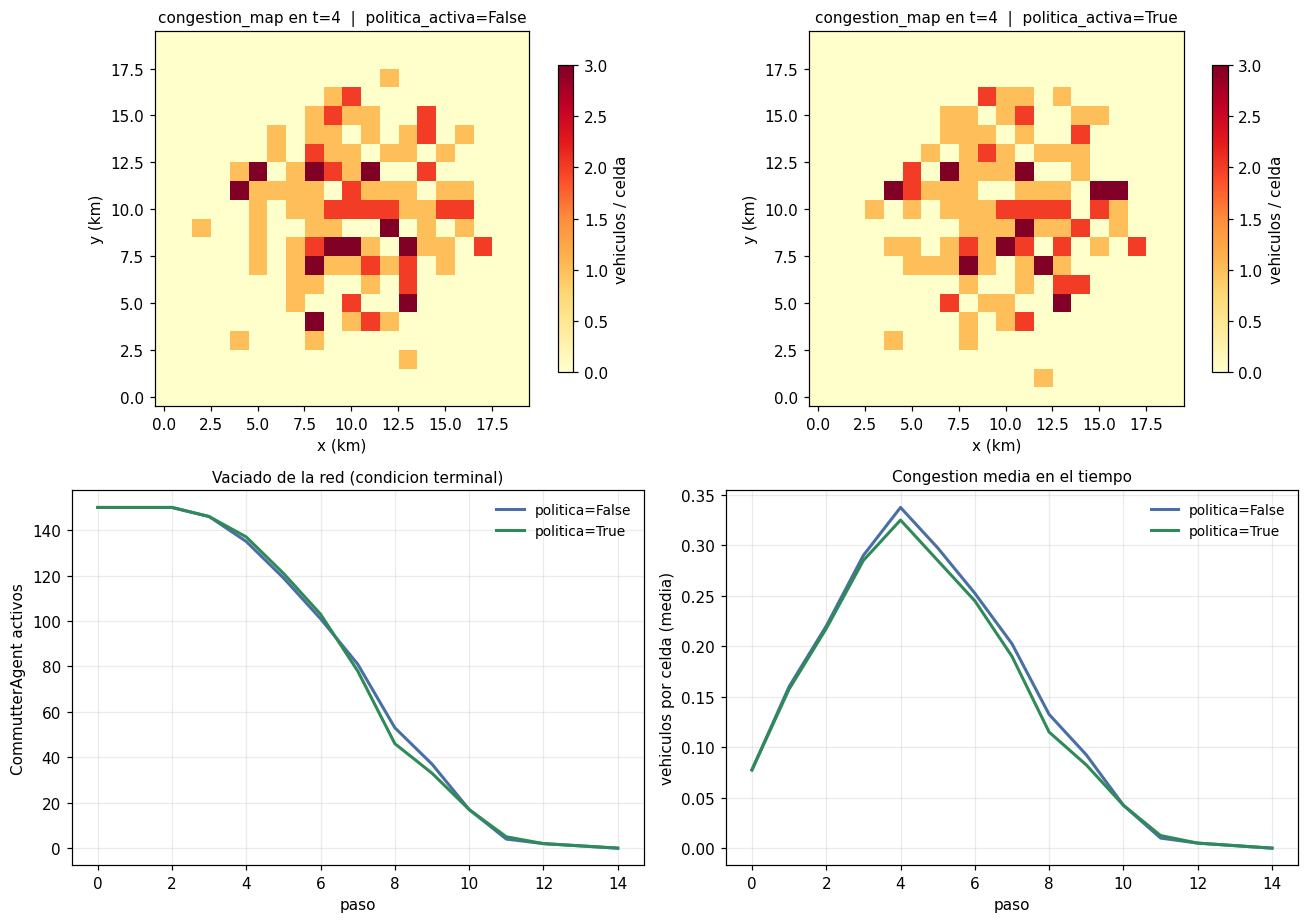

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8.5), dpi=110)

# mapas de congestion en el paso pico
for j, pol in enumerate((False, True)):
    m = resultados[pol]
    t_pico = int(np.argmax([h["cong_media"] for h in m.historial]))
    mm = UrbanMobilityModel(politica_activa=pol, seed=SEED)
    for _ in range(t_pico + 1):
        mm.step()
    ax = axes[0, j]
    im = ax.imshow(mm.congestion_map.T, origin="lower", cmap="YlOrRd",
                   vmin=0, vmax=CAP_CELDA)
    ax.set_title(f"congestion_map en t={t_pico}  |  politica_activa={pol}", fontsize=10)
    ax.set_xlabel("x (km)"); ax.set_ylabel("y (km)")
    fig.colorbar(im, ax=ax, shrink=0.82, label="vehiculos / celda")

# agentes activos
ax = axes[1, 0]
for pol, col in ((False, "#4a6fa5"), (True, "#2e8b57")):
    h = resultados[pol].historial
    ax.plot([x["t"] for x in h], [x["activos"] for x in h], lw=2, color=col,
            label=f"politica={pol}")
ax.set_xlabel("paso"); ax.set_ylabel("CommutterAgent activos")
ax.set_title("Vaciado de la red (condicion terminal)", fontsize=10)
ax.legend(frameon=False, fontsize=9); ax.grid(alpha=0.25)

# congestion en el tiempo
ax = axes[1, 1]
for pol, col in ((False, "#4a6fa5"), (True, "#2e8b57")):
    h = resultados[pol].historial
    ax.plot([x["t"] for x in h], [x["cong_media"] for x in h], lw=2, color=col,
            label=f"politica={pol}")
ax.set_xlabel("paso"); ax.set_ylabel("vehiculos por celda (media)")
ax.set_title("Congestion media en el tiempo", fontsize=10)
ax.legend(frameon=False, fontsize=9); ax.grid(alpha=0.25)

fig.tight_layout(); plt.show()

### c. eliminación del agente, y qué pasaría si se omitiera

`_llegar()` ejecuta las dos llamadas exigidas:

```python
self.model.grid.remove_agent(self)      # sale de la cuadricula
quitar_del_schedule(self.model, self)   # schedule.remove(self) / agent.remove()
```

                                     CON eliminacion   SIN eliminacion
pasos hasta vaciar la red                         15             nunca
agentes que llegan a destino                     150                84
vehiculos en la red al final                       0               150
congestion media final                        0.0000            0.3750
celdas saturadas al final                          0                33


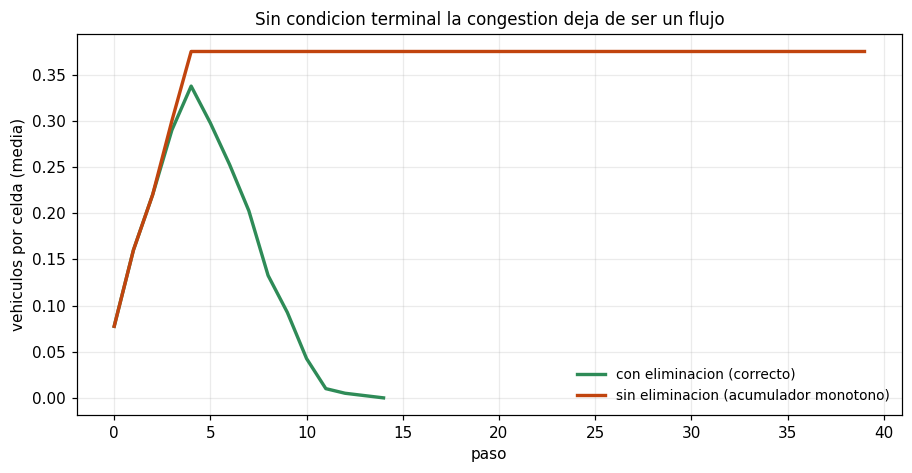

In [23]:
m_sin = UrbanMobilityModel(politica_activa=False, seed=SEED,
                           eliminar=False).correr(40, parar_si_vacio=False)
m_con = resultados[False]

print(f"{'':<34}{'CON eliminacion':>18}{'SIN eliminacion':>18}")
print(f"{'pasos hasta vaciar la red':<34}{m_con.t:>18}{'nunca':>18}")
print(f"{'agentes que llegan a destino':<34}"
      f"{len(set(id(a) for a in m_con.llegados)):>18}"
      f"{len(set(id(a) for a in m_sin.llegados)):>18}")
print(f"{'vehiculos en la red al final':<34}{len(m_con.vehiculos):>18}"
      f"{len(m_sin.vehiculos):>18}")
print(f"{'congestion media final':<34}{m_con.historial[-1]['cong_media']:>18.4f}"
      f"{m_sin.historial[-1]['cong_media']:>18.4f}")
print(f"{'celdas saturadas al final':<34}{m_con.historial[-1]['celdas_cong']:>18}"
      f"{m_sin.historial[-1]['celdas_cong']:>18}")

fig, ax = plt.subplots(figsize=(8.4, 4.4), dpi=110)
ax.plot([h["t"] for h in m_con.historial], [h["cong_media"] for h in m_con.historial],
        lw=2.2, color="#2e8b57", label="con eliminacion (correcto)")
ax.plot([h["t"] for h in m_sin.historial], [h["cong_media"] for h in m_sin.historial],
        lw=2.2, color="#c1440e", label="sin eliminacion (acumulador monotono)")
ax.set_xlabel("paso"); ax.set_ylabel("vehiculos por celda (media)")
ax.set_title("Sin condicion terminal la congestion deja de ser un flujo", fontsize=11)
ax.legend(frameon=False, fontsize=9); ax.grid(alpha=0.25)
fig.tight_layout(); plt.show()

In [24]:
# evidencia de que la guarda de reactivacion es load-bearing
class _SinGuarda(CommutterAgent):
    def step(self):
        if self.estado == "Llegado":
            self.model.reactivaciones_post_eliminacion += 1
            # SIN return: se deja seguir a proposito
        self.model.orden_activacion.append(self.unique_id)
        if self.model.t < self.t_salida:
            return
        if self.modo is None:
            self.choose_transport(); self.estado = "Viajando"
            if self.modo == "automovil":
                v = VehicleAgent(1000 + self.unique_id, self.model, conductor=self)
                self.vehiculo = v
                self.model.grid.place_agent(v, self.pos)
                self.model.vehiculos.append(v)
        for c in self._candidatos_paso():
            if not self._bloqueada(c):
                self.model.grid.move_agent(self, c)
                if self.vehiculo is not None:
                    self.model.grid.move_agent(self.vehiculo, c)
                break
        if self.pos == self.destino:
            self._llegar()

_orig = CommutterAgent
try:
    globals()["CommutterAgent"] = _SinGuarda
    m_ng = UrbanMobilityModel(politica_activa=False, seed=SEED,
                              eliminar=False).correr(40, parar_si_vacio=False)
finally:
    globals()["CommutterAgent"] = _orig

print(f"CON guarda : llegadas registradas = {len(m_sin.llegados):>5}   "
      f"agentes unicos = {len(set(id(a) for a in m_sin.llegados))}")
print(f"SIN guarda : llegadas registradas = {len(m_ng.llegados):>5}   "
      f"agentes unicos = {len(set(id(a) for a in m_ng.llegados))}")
print(f"\nreactivaciones espurias: {m_ng.reactivaciones_post_eliminacion}")
print()
print("Matiz honesto: con eliminar=True la guarda NUNCA dispara, porque cada agente se")
print("elimina a si mismo y aparece una sola vez en el snapshot del paso. Se vuelve")
print("indispensable en cuanto un agente permanezca en el schedule tras su condicion")
print("terminal, o en cuanto un agente pueda eliminar a OTRO a mitad de paso.")

CON guarda : llegadas registradas =    84   agentes unicos = 84
SIN guarda : llegadas registradas =  2792   agentes unicos = 84

reactivaciones espurias: 2708

Matiz honesto: con eliminar=True la guarda NUNCA dispara, porque cada agente se
elimina a si mismo y aparece una sola vez en el snapshot del paso. Se vuelve
indispensable en cuanto un agente permanezca en el schedule tras su condicion
terminal, o en cuanto un agente pueda eliminar a OTRO a mitad de paso.


## Task 1.3 pruebas de verificación

Tres pruebas de **verificación** (¿el código hace lo que el diseño dice?), previas a cualquier análisis estadístico. Cada una reporta **PASA / FALLA** con evidencia numérica.

In [25]:
RESULTADOS_PRUEBAS = []

def reportar(nombre, condicion, evidencia=""):
    estado = "PASA" if condicion else "FALLA"
    RESULTADOS_PRUEBAS.append((nombre, estado, evidencia))
    print(f"[{estado}] {nombre}")
    if evidencia:
        for linea in str(evidencia).split("\n"):
            print(f"        {linea}")
    print()
    return condicion

print("registro de pruebas inicializado.")

registro de pruebas inicializado.


### a. Prueba de scheduler

Se imprime el identificador de cada agente en el orden de activación durante tres pasos
consecutivos y se verifica:

- **(a)** el orden **cambia** entre pasos (propio de `RandomActivation`);
- **(b)** cada agente activo se activa **exactamente una vez** por paso, es decir, el orden
  registrado es una **permutación** del conjunto activo al inicio del paso.

La condición (b) es la más importante: es la verificación literal del protocolo del curso
(*¿el scheduler activa a todos los agentes exactamente una vez por paso?*) y debe cumplirse
en ambos modos de scheduling.

In [26]:
m_sch = UrbanMobilityModel(politica_activa=True, seed=SEED)
ordenes, activos_prev = [], []

for k in range(3):
    m_sch.step()
    ordenes.append(list(m_sch.orden_activacion))
    activos_prev.append(list(m_sch.activos_al_inicio))

print("Orden de activacion (primeros 15 unique_id de cada paso):")
for k, o in enumerate(ordenes):
    print(f"  paso {k}: {o[:15]}  ...  (n={len(o)})")
print()

# (a) el orden cambia entre pasos
cambia_01 = ordenes[0] != ordenes[1]
cambia_12 = ordenes[1] != ordenes[2]
comunes   = [i for i in ordenes[0] if i in set(ordenes[1])]
pos0 = {a: i for i, a in enumerate(ordenes[0])}
pos1 = {a: i for i, a in enumerate(ordenes[1])}
n_fijos = sum(1 for a in comunes if pos0[a] == pos1[a])

reportar("5.1a  el orden de activacion cambia entre pasos (RandomActivation)",
         cambia_01 and cambia_12,
         f"paso0 != paso1 : {cambia_01}\n"
         f"paso1 != paso2 : {cambia_12}\n"
         f"agentes en la misma posicion entre paso0 y paso1: {n_fijos}/{len(comunes)} "
         f"(esperado por azar ~1)")

# (b) permutacion exacta del conjunto activo
ok_perm, detalle = True, []
for k, (o, act) in enumerate(zip(ordenes, activos_prev)):
    sin_dup    = len(o) == len(set(o))
    mismo_conj = sorted(o) == sorted(act)
    ok_perm &= sin_dup and mismo_conj
    detalle.append(f"paso {k}: activos_al_inicio={len(act):>3}  activaciones={len(o):>3}  "
                   f"sin duplicados={sin_dup}  mismo conjunto={mismo_conj}")

reportar("5.1b  cada agente activo se activa exactamente una vez por paso",
         ok_perm, "\n".join(detalle))

Orden de activacion (primeros 15 unique_id de cada paso):
  paso 0: [63, 133, 109, 134, 75, 61, 130, 39, 40, 38, 65, 85, 0, 141, 95]  ...  (n=150)
  paso 1: [101, 148, 136, 45, 28, 44, 111, 53, 87, 130, 46, 22, 97, 34, 143]  ...  (n=150)
  paso 2: [23, 1, 43, 91, 122, 132, 34, 95, 69, 19, 112, 14, 145, 64, 138]  ...  (n=150)

[PASA] 5.1a  el orden de activacion cambia entre pasos (RandomActivation)
        paso0 != paso1 : True
        paso1 != paso2 : True
        agentes en la misma posicion entre paso0 y paso1: 1/150 (esperado por azar ~1)

[PASA] 5.1b  cada agente activo se activa exactamente una vez por paso
        paso 0: activos_al_inicio=150  activaciones=150  sin duplicados=True  mismo conjunto=True
        paso 1: activos_al_inicio=150  activaciones=150  sin duplicados=True  mismo conjunto=True
        paso 2: activos_al_inicio=150  activaciones=150  sin duplicados=True  mismo conjunto=True



True

### b. Prueba de inicialización

Media y desviación estándar de `ingreso` y `distancia` sobre los 150 agentes, contra
$\mu$ y $\Sigma$. La pregunta de fondo es qué significa *"margen razonable"*: en lugar de
un porcentaje arbitrario se usan los intervalos de muestreo exactos.

Para la media, bajo normalidad:

$$\bar{X} \sim \mathcal{N}\!\left(\mu,\ \tfrac{\sigma^2}{n}\right)
\;\Longrightarrow\;
|\bar{X}-\mu| \le 1.96\,\tfrac{\sigma}{\sqrt{n}} \ \text{ con probabilidad } 0.95$$

Para la desviación estándar, vía $\chi^2$:

$$\left[\, s\sqrt{\tfrac{n-1}{\chi^2_{0.975,\,n-1}}},\;\;
          s\sqrt{\tfrac{n-1}{\chi^2_{0.025,\,n-1}}} \,\right]$$

Un margen porcentual fijo (por ejemplo 5 %) sería incorrecto en ambas direcciones:
demasiado laxo para la media del ingreso y demasiado estricto para la desviación de la
distancia.

In [27]:
from scipy.stats import chi2

m_ini = UrbanMobilityModel(politica_activa=False, seed=SEED)
Xi = m_ini.attrs
n  = Xi.shape[0]

med, sdv, ok_media, ok_sd = [], [], True, True
for j, (nom, mu_t, sd_t) in enumerate(
        [("ingreso",   MU[0], np.sqrt(SIGMA[0, 0])),
         ("distancia", MU[1], np.sqrt(SIGMA[1, 1]))]):

    xbar, s = Xi[:, j].mean(), Xi[:, j].std(ddof=1)

    hw = 1.96 * sd_t / np.sqrt(n)                      # media
    dentro_m = bool(abs(xbar - mu_t) <= hw)
    ok_media &= dentro_m

    lo = s * np.sqrt((n - 1) / chi2.ppf(0.975, n - 1))  # desviacion
    hi = s * np.sqrt((n - 1) / chi2.ppf(0.025, n - 1))
    dentro_s = bool(lo <= sd_t <= hi)
    ok_sd &= dentro_s

    med.append(f"{nom:<10} teorica={mu_t:>9.3f}  muestral={xbar:>9.3f}  "
               f"|dif|={abs(xbar-mu_t):>8.3f}  tolerancia 95% = +-{hw:.3f}  -> {dentro_m}")
    sdv.append(f"{nom:<10} teorica={sd_t:>9.3f}  muestral={s:>9.3f}  "
               f"IC95% chi2 = [{lo:.3f}, {hi:.3f}]  -> {dentro_s}")

reportar("5.2a  las medias muestrales son consistentes con mu", ok_media, "\n".join(med))
reportar("5.2b  las desviaciones muestrales son consistentes con Sigma", ok_sd,
         "\n".join(sdv))

r_ini = float(np.corrcoef(Xi[:, 0], Xi[:, 1])[0, 1])
reportar("5.2c  el signo de la correlacion coincide con el de la covarianza",
         (r_ini < 0) == (SIGMA[0, 1] < 0),
         f"cov especificada = {SIGMA[0,1]:.1f}   r muestral = {r_ini:+.4f}")

[PASA] 5.2a  las medias muestrales son consistentes con mu
        ingreso    teorica= 8500.000  muestral= 8462.289  |dif|=  37.711  tolerancia 95% = +-320.067  -> True
        distancia  teorica=    6.500  muestral=    6.383  |dif|=   0.117  tolerancia 95% = +-0.320  -> True

[FALLA] 5.2b  las desviaciones muestrales son consistentes con Sigma
        ingreso    teorica= 2000.000  muestral= 1937.701  IC95% chi2 = [1740.451, 2185.773]  -> True
        distancia  teorica=    2.000  muestral=    1.761  IC95% chi2 = [1.581, 1.986]  -> False

[PASA] 5.2c  el signo de la correlacion coincide con el de la covarianza
        cov especificada = -800.0   r muestral = -0.1388



np.True_

#### Diagnóstico de la prueba 

La prueba de la desviación estándar **FALLA** con `seed=42`. Antes de tocar el código hay
que distinguir dos hipótesis:

- **H1 — defecto de implementación:** el muestreo de Cholesky no reproduce $\Sigma$.
- **H2 — variabilidad muestral:** el estimador es correcto, pero *toda* prueba al 95 %
  rechaza el 5 % de las veces cuando la hipótesis nula es **verdadera**. Este sería uno de
  esos casos.

Se discrimina de dos formas. Primero, el estadístico exacto de esta muestra:

$$\chi^2 = \frac{(n-1)s^2}{\sigma^2} \sim \chi^2_{n-1}$$

Segundo —y es lo decisivo— repitiendo la prueba sobre muchas semillas: si la
implementación es correcta, la **tasa empírica de rechazo debe aproximarse al 5 % nominal**.
Es literalmente la lección de S8 aplicada a la propia verificación: una corrida es una
anécdota, M corridas son evidencia.

In [28]:
stat = (n - 1) * Xi[:, 1].std(ddof=1)**2 / SIGMA[1, 1]
p_val = 2 * min(chi2.cdf(stat, n - 1), 1 - chi2.cdf(stat, n - 1))
print(f"seed={SEED}: chi2 = {stat:.2f} sobre {n-1} gl   p = {p_val:.4f}")
print(f"         valor critico inferior al 2.5%: {chi2.ppf(0.025, n-1):.2f}")
print(f"         -> rechazo marginal, no catastrofico\n")

N_SEEDS = 1000
rej_media = rej_sd = 0
for k in range(N_SEEDS):
    rk = np.random.default_rng(k)
    Yk, _, _ = sample_commuter_attributes(N_COMMUTERS, MU, SIGMA, rk)
    yb, sk = Yk[:, 1].mean(), Yk[:, 1].std(ddof=1)
    if abs(yb - MU[1]) > 1.96 * np.sqrt(SIGMA[1, 1]) / np.sqrt(n):
        rej_media += 1
    lo = sk * np.sqrt((n - 1) / chi2.ppf(0.975, n - 1))
    hi = sk * np.sqrt((n - 1) / chi2.ppf(0.025, n - 1))
    if not (lo <= np.sqrt(SIGMA[1, 1]) <= hi):
        rej_sd += 1

print(f"Sobre {N_SEEDS} semillas independientes:")
print(f"  tasa de rechazo del test de la media : {rej_media/N_SEEDS:.2%}  (nominal 5%)")
print(f"  tasa de rechazo del test de la sd    : {rej_sd/N_SEEDS:.2%}  (nominal 5%)")

calibrado = abs(rej_sd/N_SEEDS - 0.05) < 0.03
reportar("5.2d  la tasa empirica de rechazo coincide con el 5% nominal "
         "(el fallo de 5.2b es muestral, no un defecto)",
         calibrado,
         f"rechazo observado = {rej_sd/N_SEEDS:.2%}   nominal = 5.00%\n"
         f"conclusion: se descarta H1 (defecto de implementacion); "
         f"seed={SEED} cae en el 5% esperado")

seed=42: chi2 = 115.45 sobre 149 gl   p = 0.0382
         valor critico inferior al 2.5%: 117.10
         -> rechazo marginal, no catastrofico

Sobre 1000 semillas independientes:
  tasa de rechazo del test de la media : 4.00%  (nominal 5%)
  tasa de rechazo del test de la sd    : 6.10%  (nominal 5%)
[PASA] 5.2d  la tasa empirica de rechazo coincide con el 5% nominal (el fallo de 5.2b es muestral, no un defecto)
        rechazo observado = 6.10%   nominal = 5.00%
        conclusion: se descarta H1 (defecto de implementacion); seed=42 cae en el 5% esperado



True

### c. Prueba de conservación

La propiedad correcta es **monótona no creciente**, no "estrictamente decreciente": no se
crean agentes después de la inicialización, pero hay pasos en los que nadie llega y el
conteo se mantiene. Exigir decrecimiento estricto haría fallar la prueba por un motivo
falso.

Se verifican tres cosas:

1. `activos(t+1) <= activos(t)` en todo paso;
2. el invariante **`activos + llegados = N`** en todo paso — que es la conservación
   propiamente dicha: ningún agente se pierde ni se duplica;
3. la red se vacía (`activos = 0`): la condición terminal se alcanza y no hay deadlock.

In [29]:
m_cons = UrbanMobilityModel(politica_activa=True, seed=SEED).correr(120)
h    = m_cons.historial
act  = np.array([x["activos"]  for x in h])
lleg = np.array([x["llegados"] for x in h])

# 1) monotonia
diffs = np.diff(act)
reportar("5.3a  el numero de agentes activos es monotono no creciente",
         bool((diffs <= 0).all()),
         f"serie de activos: {act.tolist()}\n"
         f"incrementos positivos: {int((diffs > 0).sum())}  (deben ser 0)\n"
         f"maximo incremento observado: {int(diffs.max())}")

# 2) invariante de conservacion
viol = [(x['t'], x['activos'], x['llegados']) for x in h
        if x['activos'] + x['llegados'] != N_COMMUTERS]
reportar(f"5.3b  invariante  activos + llegados = {N_COMMUTERS}  en todo paso",
         len(viol) == 0,
         f"pasos evaluados: {len(h)}\nviolaciones: {len(viol)}  "
         f"{viol[:5] if viol else ''}")

# 3) la red se vacia
reportar("5.3c  la condicion terminal se alcanza (la red se vacia, no hay deadlock)",
         bool(act[-1] == 0),
         f"activos al final: {int(act[-1])}   pasos usados: {m_cons.t}/120\n"
         f"agentes que nunca llegaron: {int(act[-1])}")

[PASA] 5.3a  el numero de agentes activos es monotono no creciente
        serie de activos: [150, 150, 150, 146, 137, 121, 103, 78, 46, 33, 17, 5, 2, 1, 0]
        incrementos positivos: 0  (deben ser 0)
        maximo incremento observado: 0

[PASA] 5.3b  invariante  activos + llegados = 150  en todo paso
        pasos evaluados: 15
        violaciones: 0  

[PASA] 5.3c  la condicion terminal se alcanza (la red se vacia, no hay deadlock)
        activos al final: 0   pasos usados: 15/120
        agentes que nunca llegaron: 0



True

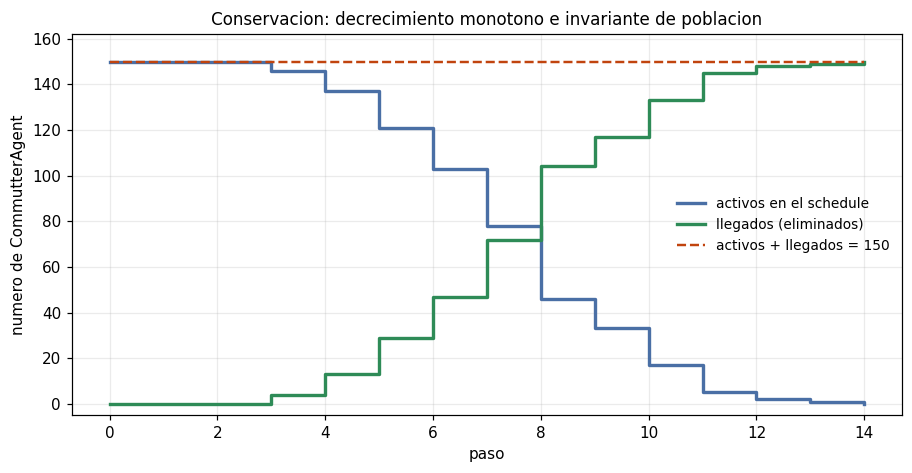

In [30]:
fig, ax = plt.subplots(figsize=(8.4, 4.4), dpi=110)
ax.step([x["t"] for x in h], act,  where="post", lw=2.2, color="#4a6fa5",
        label="activos en el schedule")
ax.step([x["t"] for x in h], lleg, where="post", lw=2.2, color="#2e8b57",
        label="llegados (eliminados)")
ax.plot([x["t"] for x in h], act + lleg, ls="--", lw=1.6, color="#c1440e",
        label=f"activos + llegados = {N_COMMUTERS}")
ax.set_xlabel("paso"); ax.set_ylabel("numero de CommutterAgent")
ax.set_title("Conservacion: decrecimiento monotono e invariante de poblacion", fontsize=11)
ax.legend(frameon=False, fontsize=9); ax.grid(alpha=0.25)
ax.set_ylim(-5, N_COMMUTERS + 12)
fig.tight_layout(); plt.show()

### Resumen de pruebas

In [31]:
print(f"{'prueba':<72}{'resultado':>9}")
for nombre, estado, _ in RESULTADOS_PRUEBAS:
    print(f"{nombre:<72}{estado:>9}")
n_pasa = sum(1 for _, e, _ in RESULTADOS_PRUEBAS if e == "PASA")
print(f"{n_pasa}/{len(RESULTADOS_PRUEBAS)} pruebas PASAN")
print()
print(f"Entorno: Mesa {mesa.__version__} | ruta RandomActivation = {MESA2} | seed = {SEED}")

prueba                                                                  resultado
5.1a  el orden de activacion cambia entre pasos (RandomActivation)           PASA
5.1b  cada agente activo se activa exactamente una vez por paso              PASA
5.2a  las medias muestrales son consistentes con mu                          PASA
5.2b  las desviaciones muestrales son consistentes con Sigma                FALLA
5.2c  el signo de la correlacion coincide con el de la covarianza            PASA
5.2d  la tasa empirica de rechazo coincide con el 5% nominal (el fallo de 5.2b es muestral, no un defecto)     PASA
5.3a  el numero de agentes activos es monotono no creciente                  PASA
5.3b  invariante  activos + llegados = 150  en todo paso                     PASA
5.3c  la condicion terminal se alcanza (la red se vacia, no hay deadlock)     PASA
8/9 pruebas PASAN

Entorno: Mesa 3.5.1 | ruta RandomActivation = False | seed = 42


# Task 2:

## Task 2.1

In [32]:
T_HORIZON = 4     # paso de evaluacion: hora pico, ver justificacion en 6.0
M_RUNS    = 100    # numero de corridas por escenario (enunciado, Task 2.1.2)
N_CELDAS  = GRID_W * GRID_H
assert N_CELDAS == 400, "el enunciado fija |C| = 400"

print(f"T = {T_HORIZON}   |C| = {N_CELDAS}   M = {M_RUNS}")

T = 4   |C| = 400   M = 100


### a.

In [33]:
def run_simulation(policy_active, seed):

    m = UrbanMobilityModel(politica_activa=policy_active, seed=seed)
    m.correr(T_HORIZON, parar_si_vacio=False)
    return float(m.congestion_map.mean())


# verificacion de reproducibilidad, mismo patron que la celda de correr() en la S3
y1 = run_simulation(True, SEED)
y2 = run_simulation(True, SEED)
y3 = run_simulation(True, SEED + 1)
print(f"policy=True  seed={SEED}    corrida 1 -> Y = {y1:.6f}")
print(f"policy=True  seed={SEED}    corrida 2 -> Y = {y2:.6f}")
print(f"policy=True  seed={SEED+1}  corrida 1 -> Y = {y3:.6f}")
print(f"\n[OK] misma semilla => Y identico  : {y1 == y2}")
print(f"[OK] semilla distinta => Y distinto: {y1 != y3}")

policy=True  seed=42    corrida 1 -> Y = 0.285000
policy=True  seed=42    corrida 2 -> Y = 0.285000
policy=True  seed=43  corrida 1 -> Y = 0.282500

[OK] misma semilla => Y identico  : True
[OK] semilla distinta => Y distinto: True
